# The Photoelectric Effect

In this experiment, you will investigate the photoelectric effect as a proof of the particle nature of light, and you will discover a mysterious physical constant. You will also gain experience manipulating spreadsheet data with Python, and with any luck you'll never have to use Excel again.  

By measuring the stopping potential for photoelectrons emitted under illumination by light of different wavelengths, you will connect experimentally measured voltages to fundamental physical constants.

As in the previous X-ray diffraction lab, the emphasis of this assignment is not only on generating plots, but on understanding how mathematical and computational models represent physical relationships.

---

**Chemistry Learning Objectives:**
 - C3.1: Apply the photoelectric effect to extract physical constants.
 - C3.2: Explain how the photoelectric effect suggests the existence of photons.
 - C3.3: Interpret the reasonableness of experimental data using physical reasoning.

**Programming Learning Objectives:**
- P3.1: Interpret Python functions as physical models.
- P3.2: Write modular, reusable code to process and visualize data.
- P3.3: Use `pandas` to manipulate and filter tabular (spreadsheet) data.
- P3.4: Use linear regression with `NumPy`.
- P3.5: Use for loops to automate applying functions many times.

---

<br></br>

# Warmup - Functions and Abstraction

In this notebook, we will use **Python functions** to represent relationships between physical quantities. A Python function is a rule that takes one or more **inputs** and returns an **output**. In the context of scientific computing, the most important point is that a function is not “just code”: it is a *model* for a relationship we believe is well-defined.

A function has three parts:

1. **Inputs (arguments):** the quantities you provide to the function.
2. **The rule:** the operations that transform inputs into an output.
3. **Output (return value):** the quantity the function produces.

For example, if `lam_nm` is a wavelength in nanometers, a conversion function might map

$$
\lambda \ \mapsto\ f
$$

meaning: “given a wavelength, return the corresponding frequency.” In Python, this looks like a function that takes a number (or an array of numbers) and returns a number (or array).

In this lab, we will repeatedly use functions to carry out transformations that mirror the analysis steps you perform conceptually:

1. **Convert light properties**
   $$
   \lambda \ \mapsto\ f, \qquad f \ \mapsto\ E_{\text{photon}}
   $$
2. **Extract a stopping potential from an I–V dataset**
   $$
   \{(V, I)\} \ \mapsto\ V_0
   $$
3. **Use a linear model to extract constants**
   $$
   f \ \mapsto\ V_0 \quad \Rightarrow \quad \text{slope and intercept}
   $$

A major advantage of functions is that they allow you to apply the *same* rule consistently across many datasets. For example, once you have a reliable function for extracting $V_0$ from a current–voltage curve, you can apply it to every wavelength without repeating manual steps. This reduces errors and makes your analysis reproducible.

Finally, throughout this notebook you should be able to answer the following about any function you use:

1. What are the **inputs**, including their **units**?
2. What is the **output**, including its **units**?
3. What physical relationship or modeling assumption does the function encode?
4. How could you check that the output is reasonable (order of magnitude, limiting behavior, trends)?


## Conversions as Functions

In the photoelectric effect, the properties of light are most naturally described in terms of **wavelength**, **frequency**, and **energy**. While wavelength is the quantity selected experimentally using optical filters, the photoelectric equation is written in terms of frequency. As a result, the first step in the analysis is to convert between these representations in a consistent and transparent way.

In this part of the notebook, you will use Python functions to carry out these conversions. The goal is not simply to compute numerical values, but to understand how each function encodes a physical relationship and how the output of one function becomes the input to the next.

---

### W.A — Converting Wavelength to Frequency

` 1 point`

The frequency $f$ of light is related to its wavelength $\lambda$ by the speed of light $c$:

$$
f = \frac{c}{\lambda}
$$

In the laboratory, wavelengths are specified in **nanometers**, while frequency is typically expressed in **hertz (s$^{-1}$)**. A conversion function allows us to apply this relationship consistently for every wavelength used in the experiment.

In the code cell below, you will use a provided Python function that converts a wavelength in nanometers to a frequency in hertz.

In [ ]:
from scipy.constants import speed_of_light # in m/s

def wavelength_nm_to_thz(wavelength):
    """
    Convert a wavelength in nanometers to frequency in terahertz.

    Parameters
    ----------
    wavelength : float or array-like
        Wavelength of light in nanometers (nm).

    Returns
    -------
    frequency : float or array-like
        Frequency of light in terahertz (THz).
    """
    frequency = speed_of_light * 1e-3 / wavelength
    return frequency

428.27493999999996

### W.B - Photon Energy as a Function of Frequency

`2 points`

Once the frequency of the incident light is known, the energy of an individual photon is given by

$$
E = h f
$$

where $h$ is Planck’s constant. Although Planck’s constant will later be *determined experimentally* in this lab, it is still useful at this stage to compute photon energies in order to compare different wavelengths qualitatively.

Write a function that takes frequency in terahertz (THz) and returns photon energy in joules (J).

In [ ]:
import numpy as np
from scipy.constants import Planck # h in J/Hz

def frequency_thz_to_energy_joule(frequency_thz):
    """
    Convert frequency (THz) to photon energy (J).

    Parameters
    ----------
    frequency_thz : float or array-like
        Frequency in terahertz (THz).

    Returns
    -------
    energy_joule : float or array-like
        Photon energy in joules (J).
    """
    # TODO: implement using E = h f and convert THz -> Hz
    pass

# Quick checks
print(frequency_thz_to_energy_joule(822))  # order of magnitude ~ 1e-19 J
print(frequency_thz_to_energy_joule(np.array([822, 740])))

5.4466296633e-19
[5.44662966e-19 4.90329191e-19]


### W.C — Light Properties Table

`2 points`

In the rest of the notebook you will repeatedly need wavelength, frequency, and photon energy for the same set of filters. Rather than recomputing these values manually each time, write a function that takes a list/array of wavelengths (nm) and returns a table containing:

- wavelength (nm)
- frequency (THz)
- photon energy (J)

Your function should call your functions from Parts 2.1 and 2.2.

In [ ]:
import pandas as pd

def make_light_properties_table(wavelengths_nm):
    """
    Build a table of wavelength (nm), frequency (THz), and photon energy (J).

    Parameters
    ----------
    wavelengths_nm : array-like
        Wavelengths in nanometers (nm).

    Returns
    -------
    table : pandas.DataFrame
        Columns: wavelength_nm, frequency_thz, energy_joule
    """
    wavelengths_nm = np.array(wavelengths_nm)
    
    # TODO: compute frequency_thz using wavelength_nm_to_thz
    # TODO: compute energy_joule using frequency_thz_to_energy_joule
    # TODO: return a DataFrame with the specified columns

    pass

filters_nm = [365, 405, 436, 546, 577]
make_light_properties_table(filters_nm)


## Question W
`10 points`
- P3.1: Interpret Python functions as physical models.
- P3.2: Use functions to transform experimental data.
  
a) In this experiment, give one example of a function that maps a *measured* quantity to a *derived* quantity.

b) Why is it useful to package a repeated analysis step (such as determining $V_0$) into a function instead of doing it manually for each wavelength?

c) Suppose a function returns a stopping potential with the wrong sign. What is one physical check you could use to notice that something is inconsistent?

---

<br></br>

## Part 1 - The Experiment and the Model


### 1.1 - Experimental Measurements

The photoelectric effect was one of the pivotal proofs of quantum mechanics and led to Albert Einstein's discovery of the photon. How can such a simple experiment give us that much information?

In the photoelectric effect experiment, we shine monochromatic light on a metal cathode inside a vacuum photocell. The light can excite electrons in the metal and cause them to be emitted from the surace. The emitted electrons are collected at the anode, resulting in a measurable current.

<figure style="text-align: center;">
  <img src="https://cdn1.byjus.com/wp-content/uploads/2019/09/Experimental-study-of-photoelectric-effect.png"
       width="600">
  <figcaption style="font-size: 0.9em; margin-top: 6px;">
    Image credit: <a href="https://byjus.com/jee/photoelectric-effect/" target="_blank">
    https://byjus.com/jee/photoelectric-effect/
    </a>
  </figcaption>
</figure>

For a fixed wavelength, the applied voltage across the photocell is varied while the resulting current is recorded, producing a current–voltage (I–V) curve.

<figure style="text-align: center;">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRL1TvWZUgrBtaUMI7v-4Lj-T_jkILHP9yJHA&s"
       width="600">
  <figcaption style="font-size: 0.9em; margin-top: 6px;">
    Image credit: <a href="https://www.thestudentroom.co.uk/showthread.php?t=3318259" target="_blank">
    https://byjus.com/jee/photoelectric-effect/
    </a>
  </figcaption>
</figure>

The applied voltage *resists* the travel of the electrons, so for an electron to complete the circuit, it must have enough kinetic energy to overcome the potential between the anode and cathode. This results in less and less current as we increase the voltage (why?).

So, this experiment is able to give us a measure of how much energy the light is giving to the electrons. But how does this suggest the existence of quantum mechanics? Keep going and find out!

<br></br>

## Part 1 - Processing Spectra

Now, before we can prove quantum mechanics from our data, we must first be able to process it.

In this section, you will use the `pandas` and `NumPy` libraries to extract the stopping potential from current-voltage (I–V) data collected for a calcium cathode at four different wavelengths (200 - 350 nm in increments of 50nm).

Each dataset contains measured voltage and corresponding photocurrent values for a fixed wavelength of incident light.

Recall that the stopping potential $V_0$ is defined as the voltage at which the photocurrent becomes zero. Your task is to visualize each I–V curve and extract the stopping potential. Doing this manually would be painful (as you surely know), so we will automate it using *functions*!

---

### Part 1A — Loading and Plotting Data with `pandas` and `matplotlib`

`10 points`

Select one dataset (for example, `ca_200nm_100intens.csv`) and generate a plot of:

- Current (µA) on the y-axis  
- Voltage (V) on the x-axis  

Your plot should include:
- Clearly labeled axes with units,
- A descriptive title including the wavelength,
- A linear regression of your data set (example given, students must do this themselves for all parts after this)

A couple sanity checks for your extracted value of $V_0$:
1. Does the trend in the data match the expected physical behavior?
2. At what approximate voltage does the current cross zero on your plot?

In [ ]:
# use pandas to load your dataset
# example functions here
import pandas as pd
ca_data = pd.read_csv('data/ca_200nm_25intens.csv')
ca_data

,voltage_V,current_uA
0,1.00,1.0089
1,0.95,0.9975
2,0.90,1.0117
3,0.85,1.0274
4,0.80,0.9958
...,...,...
93,-3.65,0.0151
94,-3.70,0.0046
95,-3.75,0.0000
96,-3.80,0.0089


Text(0, 0.5, 'current (uA)')

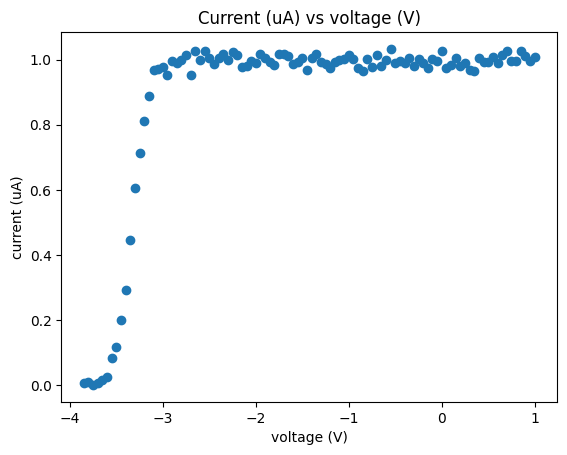

In [ ]:
# import matplotlib.pyplot as plt
# some helpful functions:
# plt.scatter(x,y), plt.plot(x,y) plt.title(title), plt.xlabel(text), plt.ylabel(text)
# in general, use plt.scatter() for experimental data and plt.plot() for regressions
import matplotlib.pyplot as plt
x = ca_data['voltage_V']
y = ca_data['current_uA']
plt.scatter(x,y)
plt.title('Current (uA) vs voltage (V)')
plt.xlabel('voltage (V)')
plt.ylabel('current (uA)')
# add linear regression code here
# it will be wrong because of zero values! this is on purpose. will motivate the filtering
# operation we do next

### 1B - Linear Regression and Root Finding with `scipy`
Now we will perform a linear regression and find where our line crosses the x axis.

Leave comments explaining what the provided code is doing.

In [ ]:
from scipy.stats import linregress

x = ca_data['voltage_V']
y = ca_data['current_uA']

regression_data = linregress(x,y)
slope = regression_data[0]
intercept = regression_data[1]
print(slope)
print(intercept)
# give them a helper function which returns the root from a linear regression.
# or have them implement that themselves.

0.11914126325319256
1.0568701776868197


Text(0, 0.5, 'current (uA)')

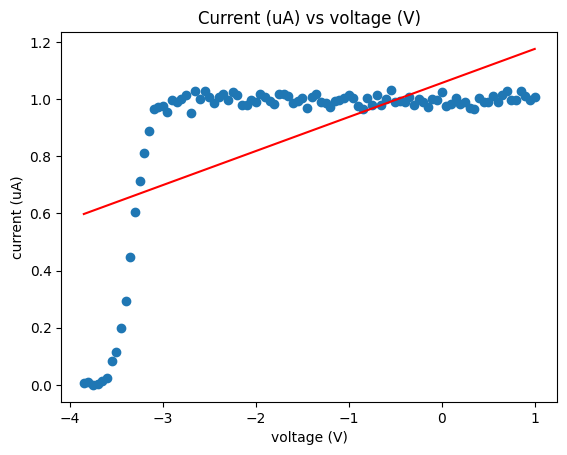

In [ ]:
# plotting code goes here
# this is how we typically visualize a line of best fit with matplotlib
regress_y = slope * x + intercept # this gives us an array of predicted values
plt.scatter(x,y)
plt.plot(x,regress_y,color='red')

# fill in formatting keywords
plt.title('Current (uA) vs voltage (V)')
plt.xlabel('voltage (V)')
plt.ylabel('current (uA)')

### 1C - Filtering Tabular Data with `pandas`
Okay, that looks pretty terrible! Clearly this line of best fit cannot be used to get the stopping potential from our dataset. We will need to *filter* our data so that we are only using values from the linear region.

This will require filtering out data from both the zero current and saturation current regions. Fortunately for us, `pandas` makes this very easy to do. An example is provided for filtering out the saturation current region; **your task** will be to filter out the zero current region and re-create the plot.

In [ ]:
sat_current = max(ca_data['current_uA']) # the saturation current
# comparision operators on arrays return arrays of true/false values for filtering
sat_filter = y < (sat_current * 0.9) # add threshold
# define the zero filter here. Don't use == 0; use a small threshold (i.e 10% of saturation current)
zero_filter = y > (sat_current * 0.1) # your code here
# we can combine filters with '&' 
total_filter = sat_filter & zero_filter 

# now we can filter our data!
x_filter = x[total_filter]
y_filter = y[total_filter] # okay this is actually much better. less going on if we use x and y

In [ ]:
# perform a linear regression on filtered data using linregress(x_array,y_array)
regress = linregress(x_filter,y_filter)
slope = regress[0]
intercept = regress[1]
# make an array of fitted values by applying your slope and intercept to your x values
y_filter_fit = x_filter * slope + intercept

Text(0, 0.5, 'current (uA)')

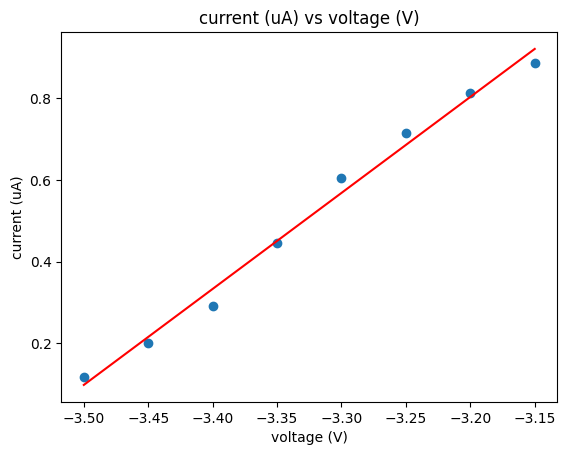

In [ ]:
# plot your data again with plt.scatter(x_arr,y_arr) for experiment and plt.plot(x_arr,y_arr) for regression
plt.scatter(x_filter,y_filter) # probably we provide part to students so they don't get stuck
plt.plot(x_filter,y_filter_fit,color='red')
plt.title("current (uA) vs voltage (V)")
plt.xlabel("voltage (V)")
plt.ylabel("current (uA)")

## Question 1
some questions....



## Part 2 - Now make it automatic

`make this part short because students will need to scroll back and forth`
This is the best thing about Python compared to Excel. In Excel, you would need to do this 9 times by hand to get data. In Python, doing it once is as good as doing it 100 times. Just write a function.

We should actually put a break here. basically, last assignment was focused on numpy and pandas and processing one thing. we hit them with the "wasn't that hard? you don't want to do that again do you? well with python, doing it once is as good as doing a million times if you can write a function..." and we talk a bit more about abstraction and how his lets us build really big processes.

<old description from related part>
At this point you have built two reusable analysis tools:

1. A function that converts a list of wavelengths into a table of light properties:
   $$
   \lambda \mapsto (f, E_{\text{photon}})
   $$
2. A function that extracts a stopping potential from a current–voltage dataset:
   $$
   \{(V, I)\}_\lambda \mapsto V_0(\lambda)
   $$

In this part, you will combine these tools to construct a single results table for calcium that includes, for each wavelength:

- wavelength (nm),
- frequency (THz or Hz),
- photon energy (J),
- stopping potential $V_0$ (V).

This table is the input to the linear model in Part 5, where you will determine Planck’s constant and the work function.

### Part 4.1 — Light Properties Table for the Calcium Filters

Use your function from Part 2 to build a table containing wavelength, frequency, and photon energy for the four calcium wavelengths.

This table should have one row per wavelength.
</old description from related part>

### 2A - Making a function from your loose code

In [ ]:
# students should be writing their own functions without scaffolding by now.
# instructions here about what it must take in and spit out

# do NOT do this from scratch! copy/paste your code from above and modify it.
def get_V0(ca_data):
    # select I and V
    x = ca_data['voltage_V']
    y = ca_data['current_uA']
    # print("1")
    # filter flat regions at zero and saturation current
    sat_current = max(ca_data['current_uA'])
    sat_filter = y < (sat_current * 0.8) # add small threshold
    zero_filter = y > (sat_current * 0.2)

    total_filter = sat_filter & zero_filter

    # print("2")
    # now we can filter our data!
    x_filter = x[total_filter]
    y_filter = y[total_filter]

    # print("3")
    # perform linear regression
    regress = linregress(x_filter,y_filter)
    slope = regress[0]
    intercept = regress[1]
    # y_fit = x_filter * slope + intercept

    # define a function for the linear regression and pass to root
    def linear_fit(x_val):
        return slope * x_val + intercept
    data = root(linear_fit,0)

    V_0 = float(data['x'][0])
    # V0 = V_0
    # print("V_0")
    # print(V_0)
    # print(type(V0))

    # V0 is the root!
    return V_0

### 2B - Apply to *All* Datasets

`5 points`

Now apply the same stopping potential function to all your functions, using a for loop.

- `Ca_200nm`
- `Ca_250nm`
- `Ca_300nm`
- `Ca_350nm`

at the three different intensities.

Construct a results table that includes:

- wavelength (nm),
- light intensity (unit?),
- stopping potential $V_0$ (V).

-3.493575371549894
[-3.493575371549894]
-2.265639840608454
[-3.493575371549894, -2.265639840608454]
-1.4441501761995121
[-3.493575371549894, -2.265639840608454, -1.4441501761995121]
-0.8545750674423298
[-3.493575371549894, -2.265639840608454, -1.4441501761995121, -0.8545750674423298]


,wavelength,V0
0,200,-3.493575
1,250,-2.265640
2,300,-1.444150
3,350,-0.854575


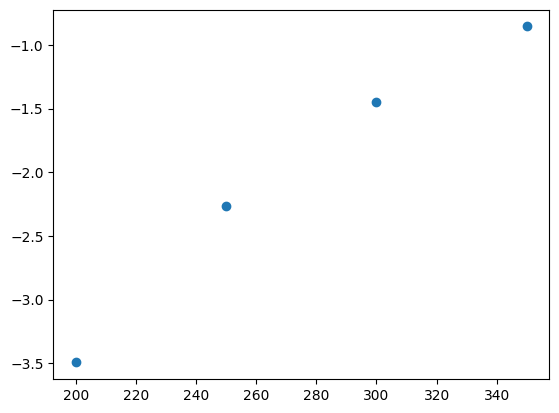

In [ ]:
# how to do this in a simple way?
# provide some of it for the students of course. they only need to implement the loop
# we need to give them the list of filenames.
import pandas as pd
from scipy.optimize import root
from scipy.stats import linregress
import matplotlib.pyplot as plt
def get_filename(wavelength,intensity):
    return f'data/ca_{wavelength}nm_{intensity}intens.csv'

# can do loops inside loops!
# really hard to do this in a very simple way for the students if we use both wavelength and intensity.T
# show one intensity.
wavelengths = [200,250,300,350]
intensities = [25,50,75,100]
intens = 100
wavelength_data = []
frequency_data = []
V0_data = []
# for wave in wavelengths:
# print("starting loop")

for wave in wavelengths:
    # print("starting again..")
    filename = get_filename(wave,intens)
    ca_data = pd.read_csv(filename)
    # call your function here!
    # append data to wavelength_data and intensity_data
    V0 = get_V0(ca_data)
    V0_data.append(V0) # the list append is good!
    print(V0)
    print(V0_data)
    wavelength_data.append(wave)
    frequency_data.append(1/wave) # this is a lie. # will fix later
    # print('1 loop')

plt.scatter(wavelength_data,V0_data)
# print(wavelength_data)
# print(V0_data)
data_dict = {
    "wavelength" : wavelength_data,
    "V0" : V0_data,
}
dataframe = pd.DataFrame(data_dict)
dataframe

### 2C - All datasets with nested for loop

In [ ]:
wavelengths = [200,250,300,350]
intensities = [25,50,75,100]
wavelength_data = []
intensity_data = []
V0_data = []
for wave in wavelengths:
  for intens in intensities:
    filename = get_filename(wave,intens)
    ca_data = pd.read_csv(filename)
    V0 = get_V0(ca_data)
    V0_data.append(V0)
    wavelength_data.append(wave)
    intensity_data.append(intens)

data_dict = {
    "V0" : V0_data,
    "wavelength (nm)" : wavelength_data,
    "intensity (percent)" : intensity_data,
}
dataframe = pd.DataFrame(data_dict)
dataframe

,V0,wavelength (nm),intensity (percent)
0,-3.519472,200,25
1,-3.525889,200,50
2,-3.525863,200,75
3,-3.493575,200,100
4,-2.272763,250,25
5,-2.286511,250,50
6,-2.286106,250,75
7,-2.265640,250,100
8,-1.439335,300,25
9,-1.450706,300,50


### 2D - make a function... again!
Suppose we want to generate our data fresh again (as in the next section). Let's make a function that does all this! Again, don't type this from scratch - you've already done all the work. you just need to organize it into something reusable.

In [ ]:
def get_data():
  wavelengths = [200,250,300,350]
  intensities = [25,50,75,100]
  wavelength_data = []
  intensity_data = []
  V0_data = []
  for wave in wavelengths:
    for intens in intensities:
      filename = get_filename(wave,intens)
      ca_data = pd.read_csv(filename)
      V0 = get_V0(ca_data)
      V0_data.append(V0)
      wavelength_data.append(wave)
      intensity_data.append(intens)

  data_dict = {
      "V0" : V0_data,
      "wavelength (nm)" : wavelength_data,
      "intensity (percent)" : intensity_data,
  }
  dataframe = pd.DataFrame(data_dict)
  return dataframe


## Problem 2

`5 points`

a) How does the stopping potential change as wavelength increases from 200 nm to 350 nm?

b) Does this trend agree with the expectation from the photoelectric equation? Explain.

c) If the 350 nm dataset showed no zero-crossing, what would that imply about the relationship between photon energy and the work function of calcium?

<br></br>

## Part 3 - Modelling Your Data

So in this part, we need to determine how the stopping potential (i.e., the maximum kinetic energy of our electrons) changes as a function of light intensity and light wavelength and frequency.

(in this part, students will plot their data in several different ways, and use linear regression to get formulas for what they decide)

We will ask students about the implications of their data.

### 3A - Changing units
students will be provided a 3d plot. students will take linear regression at each wavelength, cutoff v intensity.
likewise cutoff v frequency at each intensity. (4x4 grid maybe?)
students will say "oh real".

In [ ]:
data = get_data() # use your data function here!
data

,V0,wavelength (nm),intensity (percent)
0,-3.519472,200,25
1,-3.525889,200,50
2,-3.525863,200,75
3,-3.493575,200,100
4,-2.272763,250,25
5,-2.286511,250,50
6,-2.286106,250,75
7,-2.265640,250,100
8,-1.439335,300,25
9,-1.450706,300,50


### 3B

Text(0.5, 0, 'v0')

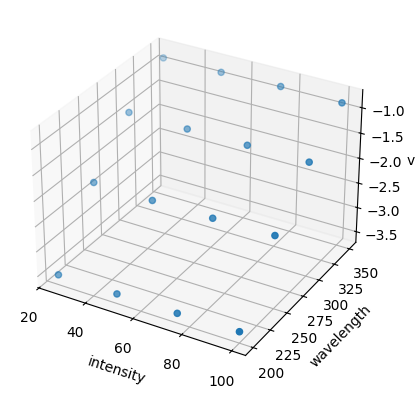

In [ ]:
# students can use their function from the warmup.
# 3d figure in matplotlib
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
v0 = data['V0']
wavelength = data['wavelength (nm)']
intensity = data['intensity (percent)']
ax.scatter(intensity,wavelength,v0)
ax.set_ylabel('wavelength')
ax.set_xlabel('intensity')
ax.set_zlabel('v0')


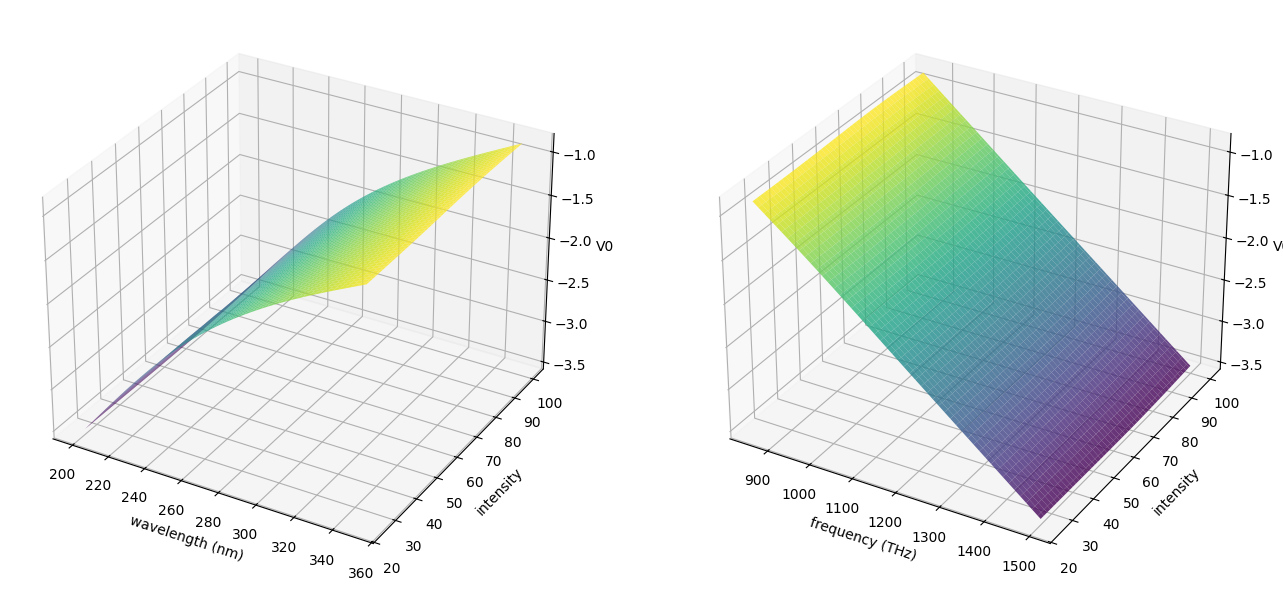

In [ ]:
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

def wavelength_to_frequency(wavelength_nm):
    """Convert wavelength in nm to frequency in Hz."""
    c = 2.998e8  # m/s
    return c / (wavelength_nm * 1e-9)

v0 = data['V0']
wavelength = data['wavelength (nm)']
intensity = data['intensity (percent)']
frequency = wavelength_to_frequency(wavelength)

def make_surface(ax, x, y, z, xlabel, ylabel, zlabel):
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)
    zi = griddata((x, y), z, (xi, yi), method='cubic')
    ax.plot_surface(xi, yi, zi, cmap='viridis', alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
make_surface(ax1, wavelength,intensity,  v0, 'wavelength (nm)','intensity',  'V0')

ax2 = fig.add_subplot(122, projection='3d')
make_surface(ax2, frequency / 1e12,intensity, v0,  'frequency (THz)', 'intensity','V0')

plt.tight_layout()
plt.show()

## Question 3

a) based on your scatterplot, how much does the max electron kinetic energy depend on the wavelength of light?

b) how about on the intensity?

c) Is your result strange? What does it suggest about the interaction between light and electrons?

## 4 — Extracting a Mysterious Physical Constant

By now we have come to the strange realization that increasing the amount of energy density of the light does not increase the kinetic energy of the emitted photons if we don't change the wavelength.

This strongly suggests that the wavelength of light controls the energy that light imparts to photons, but not the intensity. This makes no sense classically where light is regarded as a wave.

These results strongly suggest that light is quantized - that discrete interactions between particles of light and single electrons determine the emission energies. Otherwise, if light were continuous, we ought to see the stopping potential change with intensity.

---


### 5.4 Coding Activity — Determining $h$ and $\phi$ from the Calcium Data

In this section you will use your calcium results table to test the linear prediction

$V_0 = \frac{h}{e} f - \frac{\phi}{e}$.

Your tasks are:

1. Plot $V_0$ as a function of frequency
2. Fit a straight line $V_0 = mf + b$
3. Use the fitted slope and intercept to compute $h$ and $\phi$
4. Determine the cutoff frequency $f_c$ from the fitted model

Be careful with units. If your frequency column is in THz, convert to Hz before extracting $h$.


`5 points`

In [2]:
import matplotlib.pyplot as plt

# Use the results table from Part 4
# It should contain frequency and stopping potential columns
f_thz = results["frequency_thz"].to_numpy()
V0 = results["V0_volt"].to_numpy()

# TODO: plot a figure of stopping potential vs frequency. Figures should include axis labels with units and a title.
plt.figure()
plt.scatter(f_thz, V0)
plt.xlabel("Frequency f (THz)")
plt.ylabel("Stopping Potential V0 (V)")
plt.title("Calcium: Stopping Potential vs Frequency")
plt.show()

NameError: name 'results' is not defined

`5 points`

In [ ]:
from scipy.constants import e # elementary charge in Coulomb

# TODO: Convert THz (x 10**2) to Hz for correct slope units
f_hz = None

# TODO: Fit V0 = m f + b using frequency in Hz
m, b = None

print("m =", m, "V/Hz")
print("b =", b, "V")

# TODO: Compute Planck's constant and work function (check 5.3 for formulas)
# note that a volt is the electric potential difference that gives 1 joule of energy per coulomb of charge.
# i.e. V = J/C
h_exp = None
phi_exp = None

print("h_exp =", h_exp, "J s")
print("phi_exp =", phi_exp, "J")
print("phi_exp =", phi_exp / e, "eV")

`5 points`

In [ ]:
# TODO: Solve 0 = m f_c + b to find the cutoff frequency and wavelength
f_c = None
lambda_c = None

print("f_c =", f_c, "Hz")
print("lambda_c =", lambda_c, "m")
print("lambda_c =", lambda_c * 1e9, "nm")

## Question 4

`10 points`

a) Explain how the slope of your plot is related to Planck’s constant. Why must you use frequency in Hz for $h$ to have units of J s

b) The intercept of the fitted line is negative in the model. Explain why this must be the case, and interpret the intercept in terms of the work function

c) Using your fitted cutoff frequency $f_c$, explain why the condition $hf < \phi$ implies that increasing intensity cannot produce electron emission below the cutoff

d) Suppose your fitted line predicts a small negative value of $V_0$ at a frequency slightly below $f_c$. Explain why this does not imply a physically negative stopping potential, and give one experimental or analysis reason such a value could arise

e) Compare your experimental value of $h$ to the accepted value. Give one plausible experimental reason and one plausible analysis reason for any discrepancy


<br></br>

## Final Reflection

1. Your plot of $V_0$ versus frequency is approximately linear. Explain why linearity alone does not establish quantization. What specific feature of the photoelectric effect provides stronger evidence for discrete photon energy?

2. The stopping potential depends on frequency but not on intensity. Explain why this observation is inconsistent with classical wave theory.

3. Interpret the slope and intercept of your fitted line physically. What does the slope represent, and what does the intercept reveal about the metal?

4. The cutoff frequency satisfies $hf_c = \phi$. Explain why increasing light intensity cannot produce electron emission when $f < f_c$.

5. If you repeated this experiment with a different metal, which part of your graph would change and which part would remain the same? Justify your answer using the equation $V_0 = \frac{h}{e} f - \frac{\phi}{e}$.
